In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### loading data

In [ ]:
# loading the sentoment data
text_path = "../data/sentiment/archive/train_text.txt"
labels_path = "../data/sentiment/archive/train_labels.txt"

with open(text_path, "r", encoding="utf-8") as f:
    text = pd.DataFrame(
        [line.rstrip("\n") for line in f],
        columns=["text"]
    )

with open(labels_path, "r", encoding="utf-8") as f:
    labels = pd.DataFrame(
        [line.rstrip("\n") for line in f],
        columns=["label"]
    )

text["id"] = text.index
text = text[["id", "text"]]
labels["id"] = labels.index
text["label"] = list(labels["label"])
text.drop(columns="id") # drop the id



In [ ]:
# loading the common sense data (parquet)
cs = pd.read_parquet("../data/commonsense/archive/train-00000-of-00001.parquet")
cs = cs[["question", "answer"]]
cs = cs.rename({"question": "text", "answer":"label"}, axis="columns")

# make id column
cs["id"] = cs.index
cs = cs[["id", "text", "label"]]
cs.to_csv("../data/commonsense/commonsense.csv", index=False)

,text,label
0,The world trade center is no more because of 9...,yes
1,a pupil can be either a student or part of an eye,yes
2,Unity has a lot to do with family.,yes
3,Is a Mollusca a type of animal?,yes
4,Sheep are usually smaller than lambs.,no
...,...,...
9259,"A few instruments, such as a dog whistle, don'...",yes
9260,Some people do not sleep at all,no
9261,Is the French word for flower fleur?,yes
9262,A problem is an issue that is unsolved?,yes


## EDA

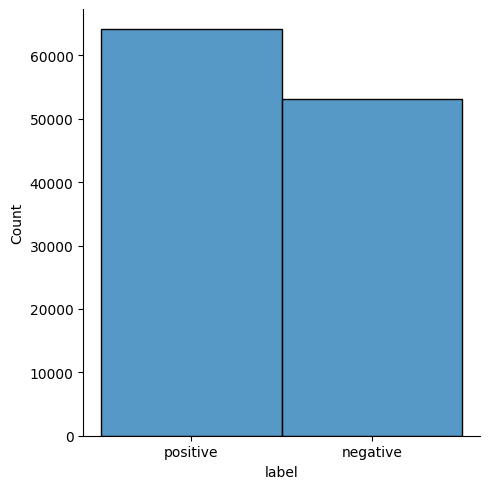

In [31]:
sns.displot(text, x="label");


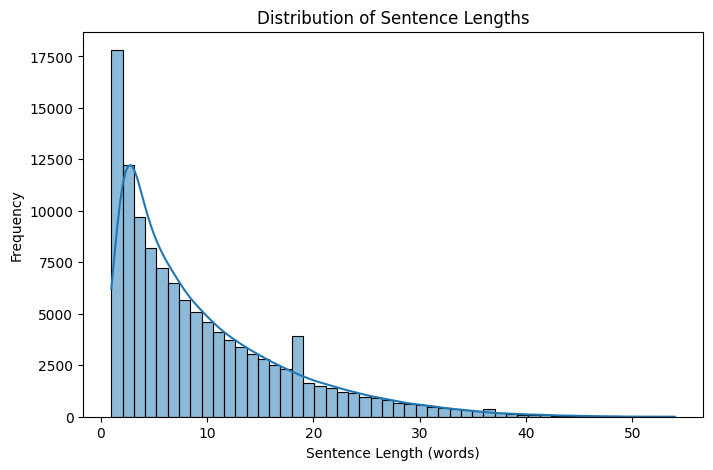

In [33]:
text["sentence_length"] = text["text"].str.split().apply(len)
plt.figure(figsize=(8, 5))

sns.histplot(
    text["sentence_length"],
    bins=50,
    kde=True
)

plt.xlabel("Sentence Length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")

plt.show()


## Data cleaning

In [ ]:
import re
def clean_filter(text):
    if re.fullmatch(r"\W+", text): # remove pure special characters like "("
        return False
    
    if re.fullmatch(r"\d+", text): # removes pure numbers
        return False
    
    return True

In [ ]:
mask = text["text"].apply(clean_filter)
clean_text = text[mask]          # kept rows
removed_text = text[~mask]       # removed rows

### Removing duplicates and semi-duplicates

Many of the sentences are near duplicates, since the dataset is a treebank.

We want to remove the semi-duplicates if the labels are identical, but keep them, if the interposed sentence changes the sentiment, and therefore the label.

**Example:**

    25861,"The film boasts at least a few good ideas and features some decent performances ,",positive

    25862,"The film boasts at least a few good ideas and features some decent performances , but",positive

    25863,"The film boasts at least a few good ideas and features some decent performances , but the result is disappointing",negative

Here, if there are semi-duplicates, we remove the shortest one. So the first sentence will be removed in this case.

In [ ]:
def normalise_text(s):
    s = s.lower()  # lowercase
    s = s.replace("``", '"').replace("''", '"')  # norm the quotations
    s = re.sub(r'\s+', ' ', s) # normalise the spaces 
    s = s.strip()
    return s

def remove_semi_duplicates(df):
    """
    Removes consecutive semi-duplicate sentences that are strict prefixes of the next sentence
    if labels are the same. Keeps all sentences if labels differ.
    """
    keep_indices = []
    n = len(df)
    
    for i in range(n):
        keep = True
        # the dataset is already sorted, so only look at the next ones, and not the entire dataset.
        if i < n - 1:
            t1, l1 = normalise_text(df.iloc[i]["text"]), df.iloc[i]["label"]
            t2, l2 = normalise_text(df.iloc[i+1]["text"]), df.iloc[i+1]["label"]
            
            if t2.startswith(t1) and l1 == l2:
                # current sentence is a prefix of the next, same label -> drop current
                keep = False
        
        if keep:
            keep_indices.append(df.index[i])
    
    return df.loc[keep_indices].reset_index(drop=True)


In [ ]:
df_clean = remove_semi_duplicates(text)
print(len(text), len(df_clean)) # to see the difference

df_clean["id"] = df_clean.index # reset the id (that we dropped before)
df_clean = df_clean[["id", "text", "label"]] # rearrange the columns
df_clean.to_csv("../data/sentiment/sentiment.csv", index=False)

117220 83426


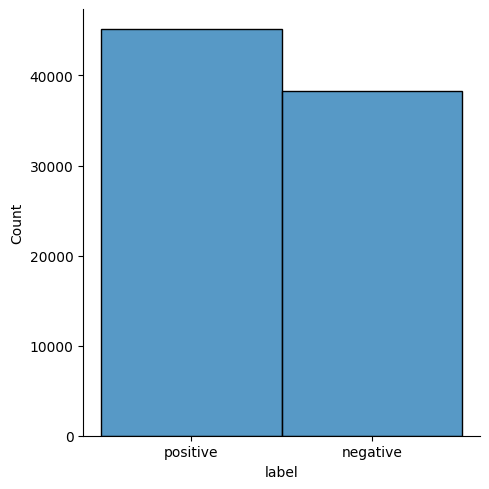

In [ ]:
sns.displot(df_clean, x="label"); # 
